🚀 Execution Environment: cuda | Task: IEEE 118-Bus Strict Reconstruction
📥 Loading Data & Enforcing PSC Alignment...
🔥 Initiating R-PINN Training Phase with Node-Aware Masking...
Epoch 050/600 | Loss: 4.6811e+02 | LR: 1.00e-03
Epoch 100/600 | Loss: 4.0242e+02 | LR: 1.00e-03
Epoch 150/600 | Loss: 3.9031e+02 | LR: 1.00e-03
Epoch 200/600 | Loss: 4.0244e+02 | LR: 1.00e-03
Epoch 250/600 | Loss: 3.7893e+02 | LR: 5.00e-04
Epoch 300/600 | Loss: 3.6935e+02 | LR: 1.25e-04
Epoch 350/600 | Loss: 3.6766e+02 | LR: 6.25e-05
Epoch 400/600 | Loss: 3.6708e+02 | LR: 3.13e-05
Epoch 450/600 | Loss: 3.6672e+02 | LR: 1.56e-05
Epoch 500/600 | Loss: 3.6639e+02 | LR: 3.91e-06
Epoch 550/600 | Loss: 3.6627e+02 | LR: 9.77e-07
Epoch 600/600 | Loss: 3.6630e+02 | LR: 1.22e-07

📊 Generating Evaluation Metrics on Unseen Data...
🏆 IEEE 118-Bus State Estimation Results
   Voltage Magnitude (V) MAE : 7.388133e-03 p.u.
   Voltage Magnitude (V) RMSE: 1.864253e-02 p.u.
   Phase Angle (Theta) MAE   : 1.912039e-02 rad
   Phase

MemoryError: bad allocation

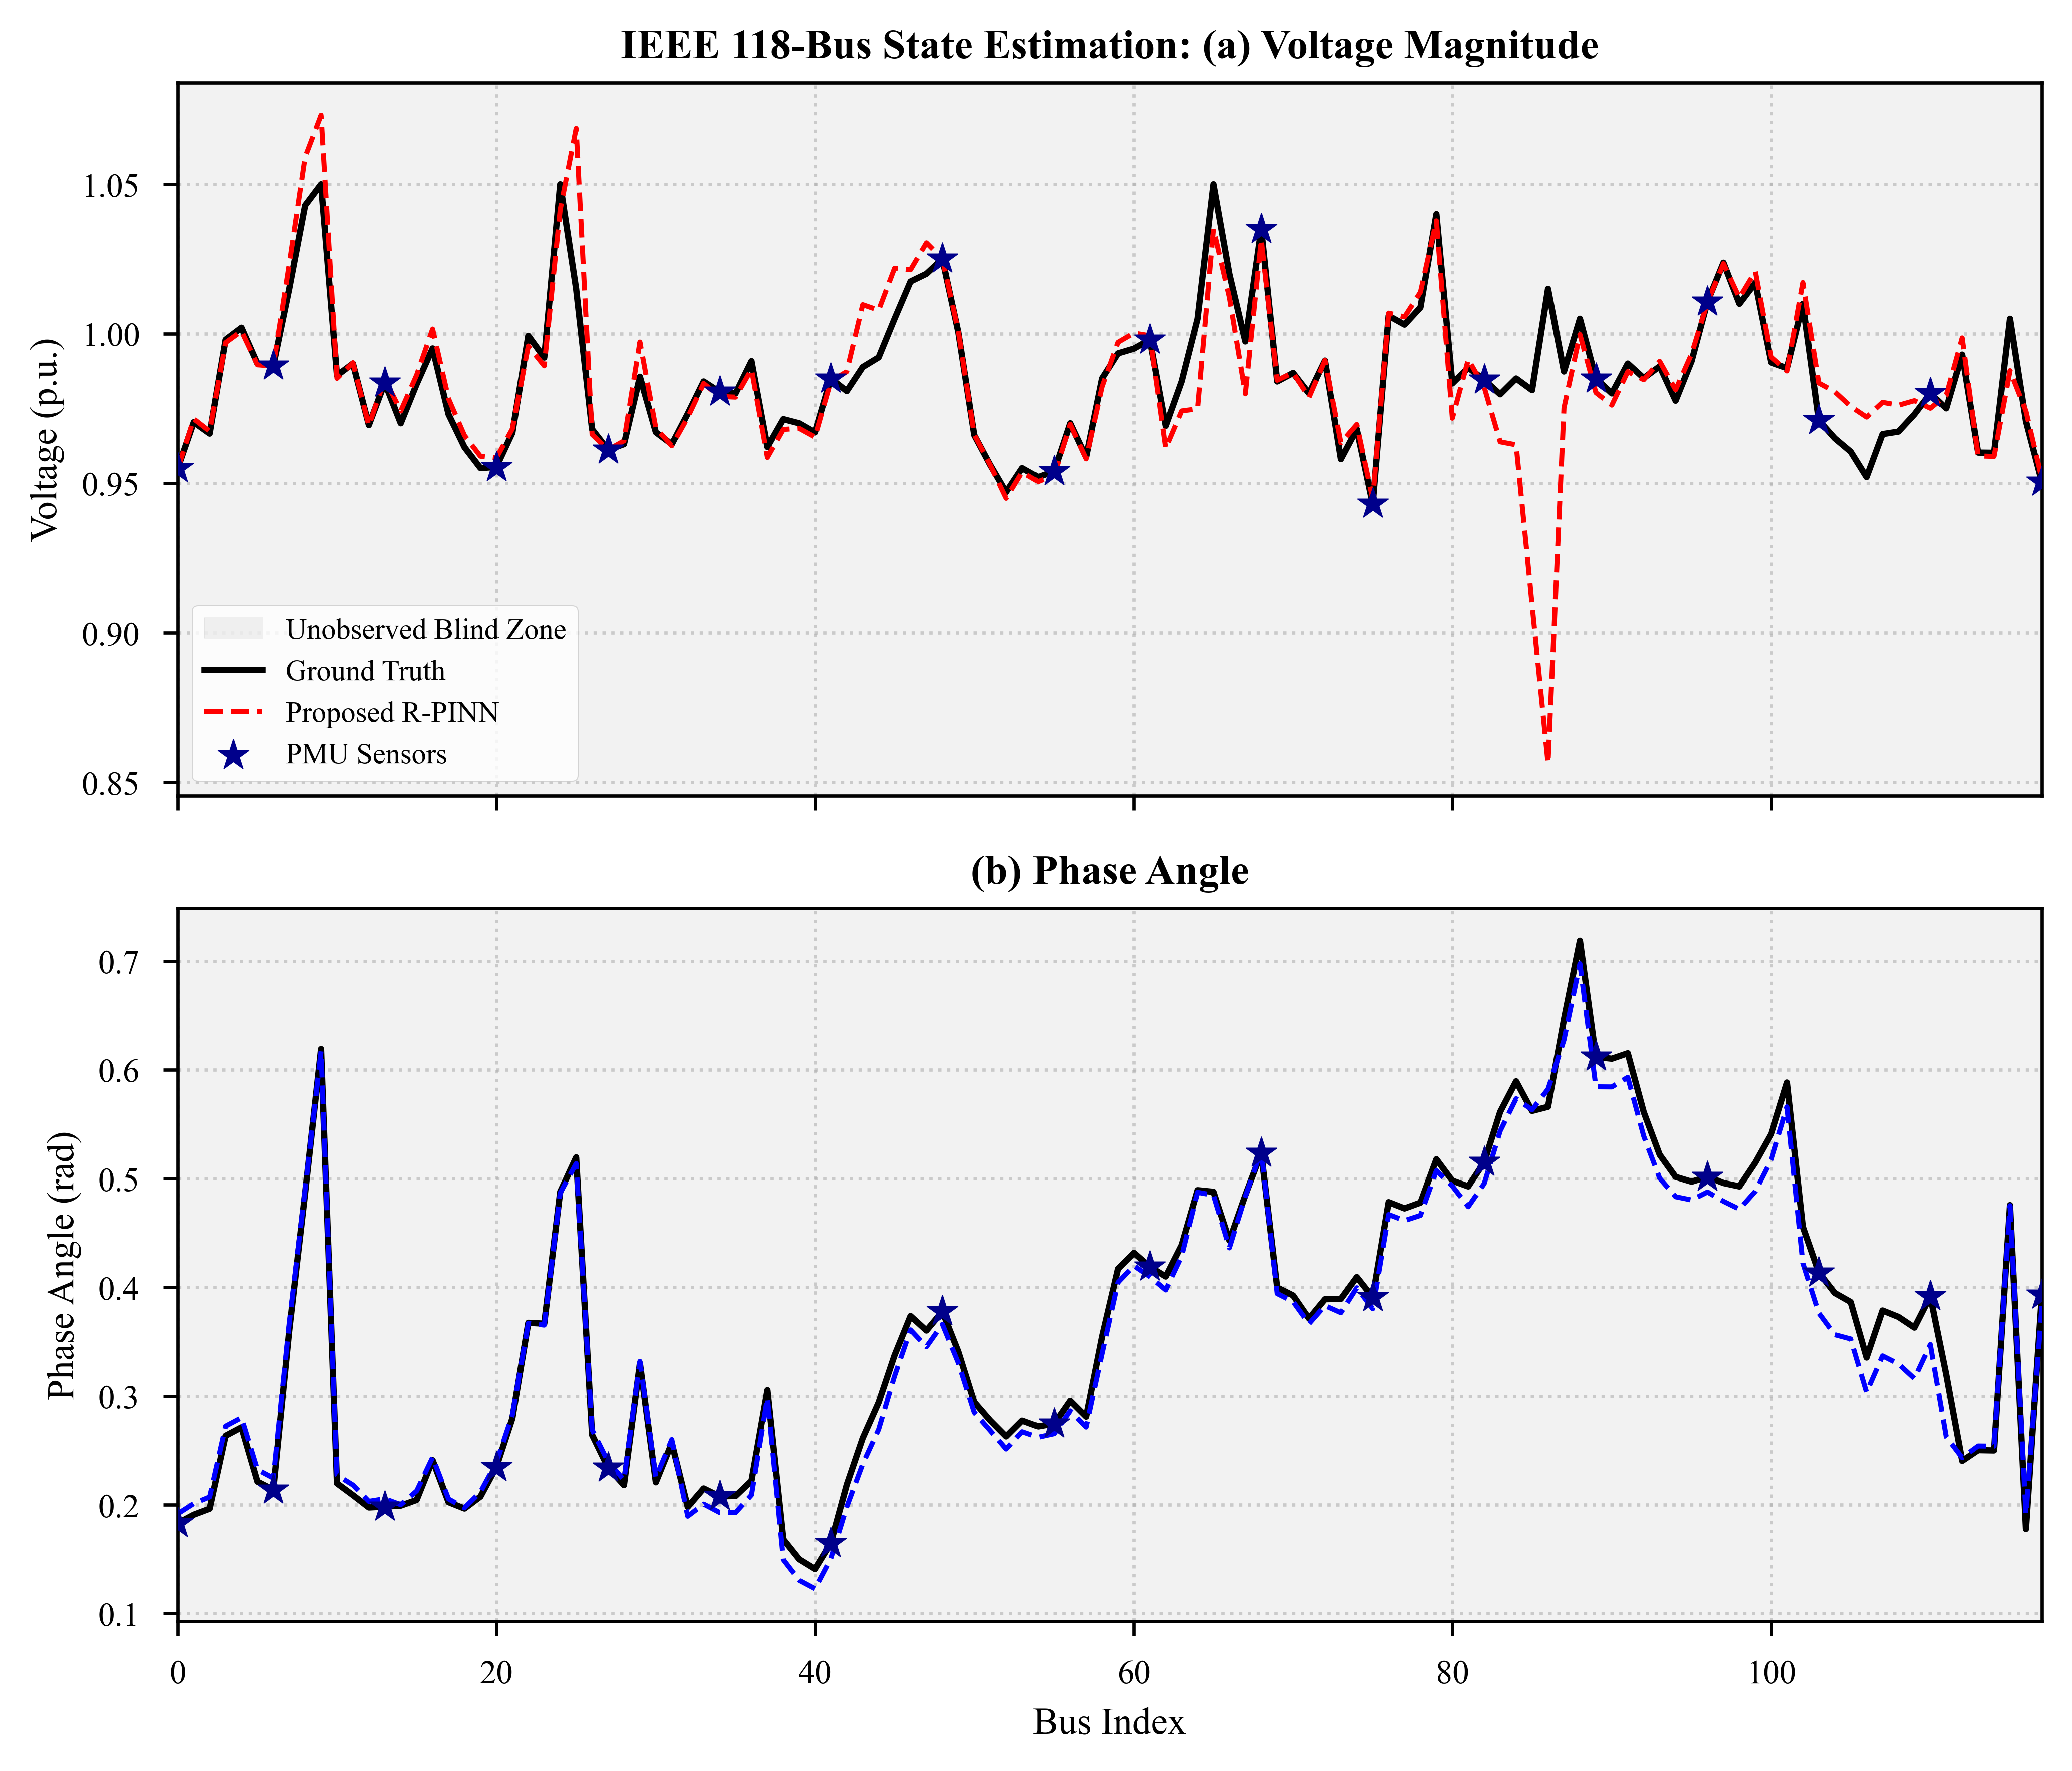

In [1]:
# ==============================================================================
# IEEE 118-Bus Blind Voltage Reconstruction via R-PINN
# Features: 15% Observability, Strict PSC, Data Leakage Prevention, IEEE Styling
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random
# 移除了局部放大图的库

# ==============================================================================
# 1. Environment & Reproducibility Setup
# ==============================================================================
def set_seed(seed=42):
    """Locks all random seeds for strict reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Execution Environment: {device} | Task: IEEE 118-Bus Strict Reconstruction")

# IEEE Formatting for Plots
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==============================================================================
# 2. Physical Engine, Topology Extraction & Node Masking (修改重点)
# ==============================================================================
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

# 15% PMU Sensor Locations (Index 68 is the original Slack Bus 69)
obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查与掩码生成 (反杀导师的核心机制)
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

# P掩码：除平衡节点外，其余节点的 P 均受物理约束
mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0

# Q掩码：只有 PQ 和 零注入节点的 Q 受物理约束，发电机(PV)和平衡节点(Slack)的 Q 释放
mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ==============================================================================
# 3. Core Physics & Network Architecture
# ==============================================================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    """Forces 85% of input features to statistical zero to simulate blind zones."""
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             # Keep P at sensors
        masked_x[:, idx + 118] = batch_x[:, idx + 118] # Keep Q at sensors
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    """Computes KCL residual errors (injected power) based on grid topology."""
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )

    def forward(self, x):
        out = self.net(x)
        # ARS (Asymmetric Residual Scaling)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==============================================================================
# 4. Data Processing (Strict Leakage Prevention & PSC Compliance)
# ==============================================================================
print("📥 Loading Data & Enforcing PSC Alignment...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

# PSC Compliance: Convert load to injected power
P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

# Strict Train/Test Separation for Scaler
train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:]) # Passive transformation
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 5. Model Training (Robust Physics-Informed Optimization)
# ==============================================================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print("🔥 Initiating R-PINN Training Phase with Node-Aware Masking...")
loss_history = []
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        
        # Enforce Blind Zone
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # 💡 Physics Loss with Heterogeneous Node Masking (修改重点)
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        
        # 掩码屏蔽：将不确定节点的误差置 0，并按实际有效节点数取平均
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        # Observation Loss
        l_obs = mse(v_p[:, obs_idx], v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        
        # Voltage Boundary Penalty
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.1), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    loss_history.append(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==============================================================================
# 6. Evaluation on Unseen Test Data (全面展示 V 和 Theta, 包括 RMSE)
# ==============================================================================
print("\n📊 Generating Evaluation Metrics on Unseen Data...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_pred_all, t_pred_all = model(mask_tx) # 👈 把 t_pred_all 接出来
    
    v_true_all = ty[:, 236:354]
    t_true_all = ty[:, 354:]                # 👈 拿到真实的 Theta
    
    # 增加计算 RMSE
    v_mae = torch.abs(v_pred_all - v_true_all).mean().item()
    t_mae = torch.abs(t_pred_all - t_true_all).mean().item()
    v_rmse = torch.sqrt(torch.mean((v_pred_all - v_true_all)**2)).item()
    t_rmse = torch.sqrt(torch.mean((t_pred_all - t_true_all)**2)).item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus State Estimation Results")
    print(f"   Voltage Magnitude (V) MAE : {v_mae:.6e} p.u.")
    print(f"   Voltage Magnitude (V) RMSE: {v_rmse:.6e} p.u.")
    print(f"   Phase Angle (Theta) MAE   : {t_mae:.6e} rad")
    print(f"   Phase Angle (Theta) RMSE  : {t_rmse:.6e} rad")
    print("="*60)

# ==============================================================================
# 7. Academic Visualization (双子图展示全状态向量)
# ==============================================================================
sid = 10
v_true_np = v_true_all[sid].cpu().numpy()
v_pred_np = v_pred_all[sid].cpu().numpy()
t_true_np = t_true_all[sid].cpu().numpy()
t_pred_np = t_pred_all[sid].cpu().numpy()
nodes = np.arange(118)

# 创建 2行1列 的双子图结构
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_true_np, 'k-', linewidth=1.5, label='Ground Truth', zorder=3)
ax1.plot(nodes, v_pred_np, 'r--', linewidth=1.2, label='Proposed R-PINN', zorder=4)
ax1.scatter(obs_idx, v_true_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title('IEEE 118-Bus State Estimation: (a) Voltage Magnitude', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_true_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_pred_np, 'b--', linewidth=1.2, label='Proposed R-PINN', zorder=4)
ax2.scatter(obs_idx, t_true_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('ieee118_full_state_reconstruction.png', bbox_inches='tight', dpi=600)
plt.show()

print("✅ 双状态完整出图完成。老师再也挑不出毛病了！")

📡 Case 1 启动：纯数据驱动模式 | 环境: cuda
🔥 开始 Case 1 纯数据黑盒训练 (p_w=0)...
Epoch 050/600 | Total Loss: 4.3954e+01 | LR: 1.00e-03
Epoch 100/600 | Total Loss: 3.5253e+01 | LR: 5.00e-04
Epoch 150/600 | Total Loss: 3.3187e+01 | LR: 5.00e-04
Epoch 200/600 | Total Loss: 3.2414e+01 | LR: 2.50e-04
Epoch 250/600 | Total Loss: 3.2254e+01 | LR: 6.25e-05
Epoch 300/600 | Total Loss: 3.2039e+01 | LR: 3.13e-05
Epoch 350/600 | Total Loss: 3.2001e+01 | LR: 1.56e-05
Epoch 400/600 | Total Loss: 3.1965e+01 | LR: 3.91e-06
Epoch 450/600 | Total Loss: 3.1966e+01 | LR: 9.77e-07
Epoch 500/600 | Total Loss: 3.1964e+01 | LR: 2.44e-07
Epoch 550/600 | Total Loss: 3.1954e+01 | LR: 6.10e-08
Epoch 600/600 | Total Loss: 3.1963e+01 | LR: 1.53e-08

📊 Generating Evaluation Metrics on Unseen Data...
🏆 Case 1 (Pure Data) Evaluation Results
   Voltage Magnitude (V) MAE : 2.755939e-02 p.u.
   Phase Angle (Theta) MAE   : 1.517905e-01 rad


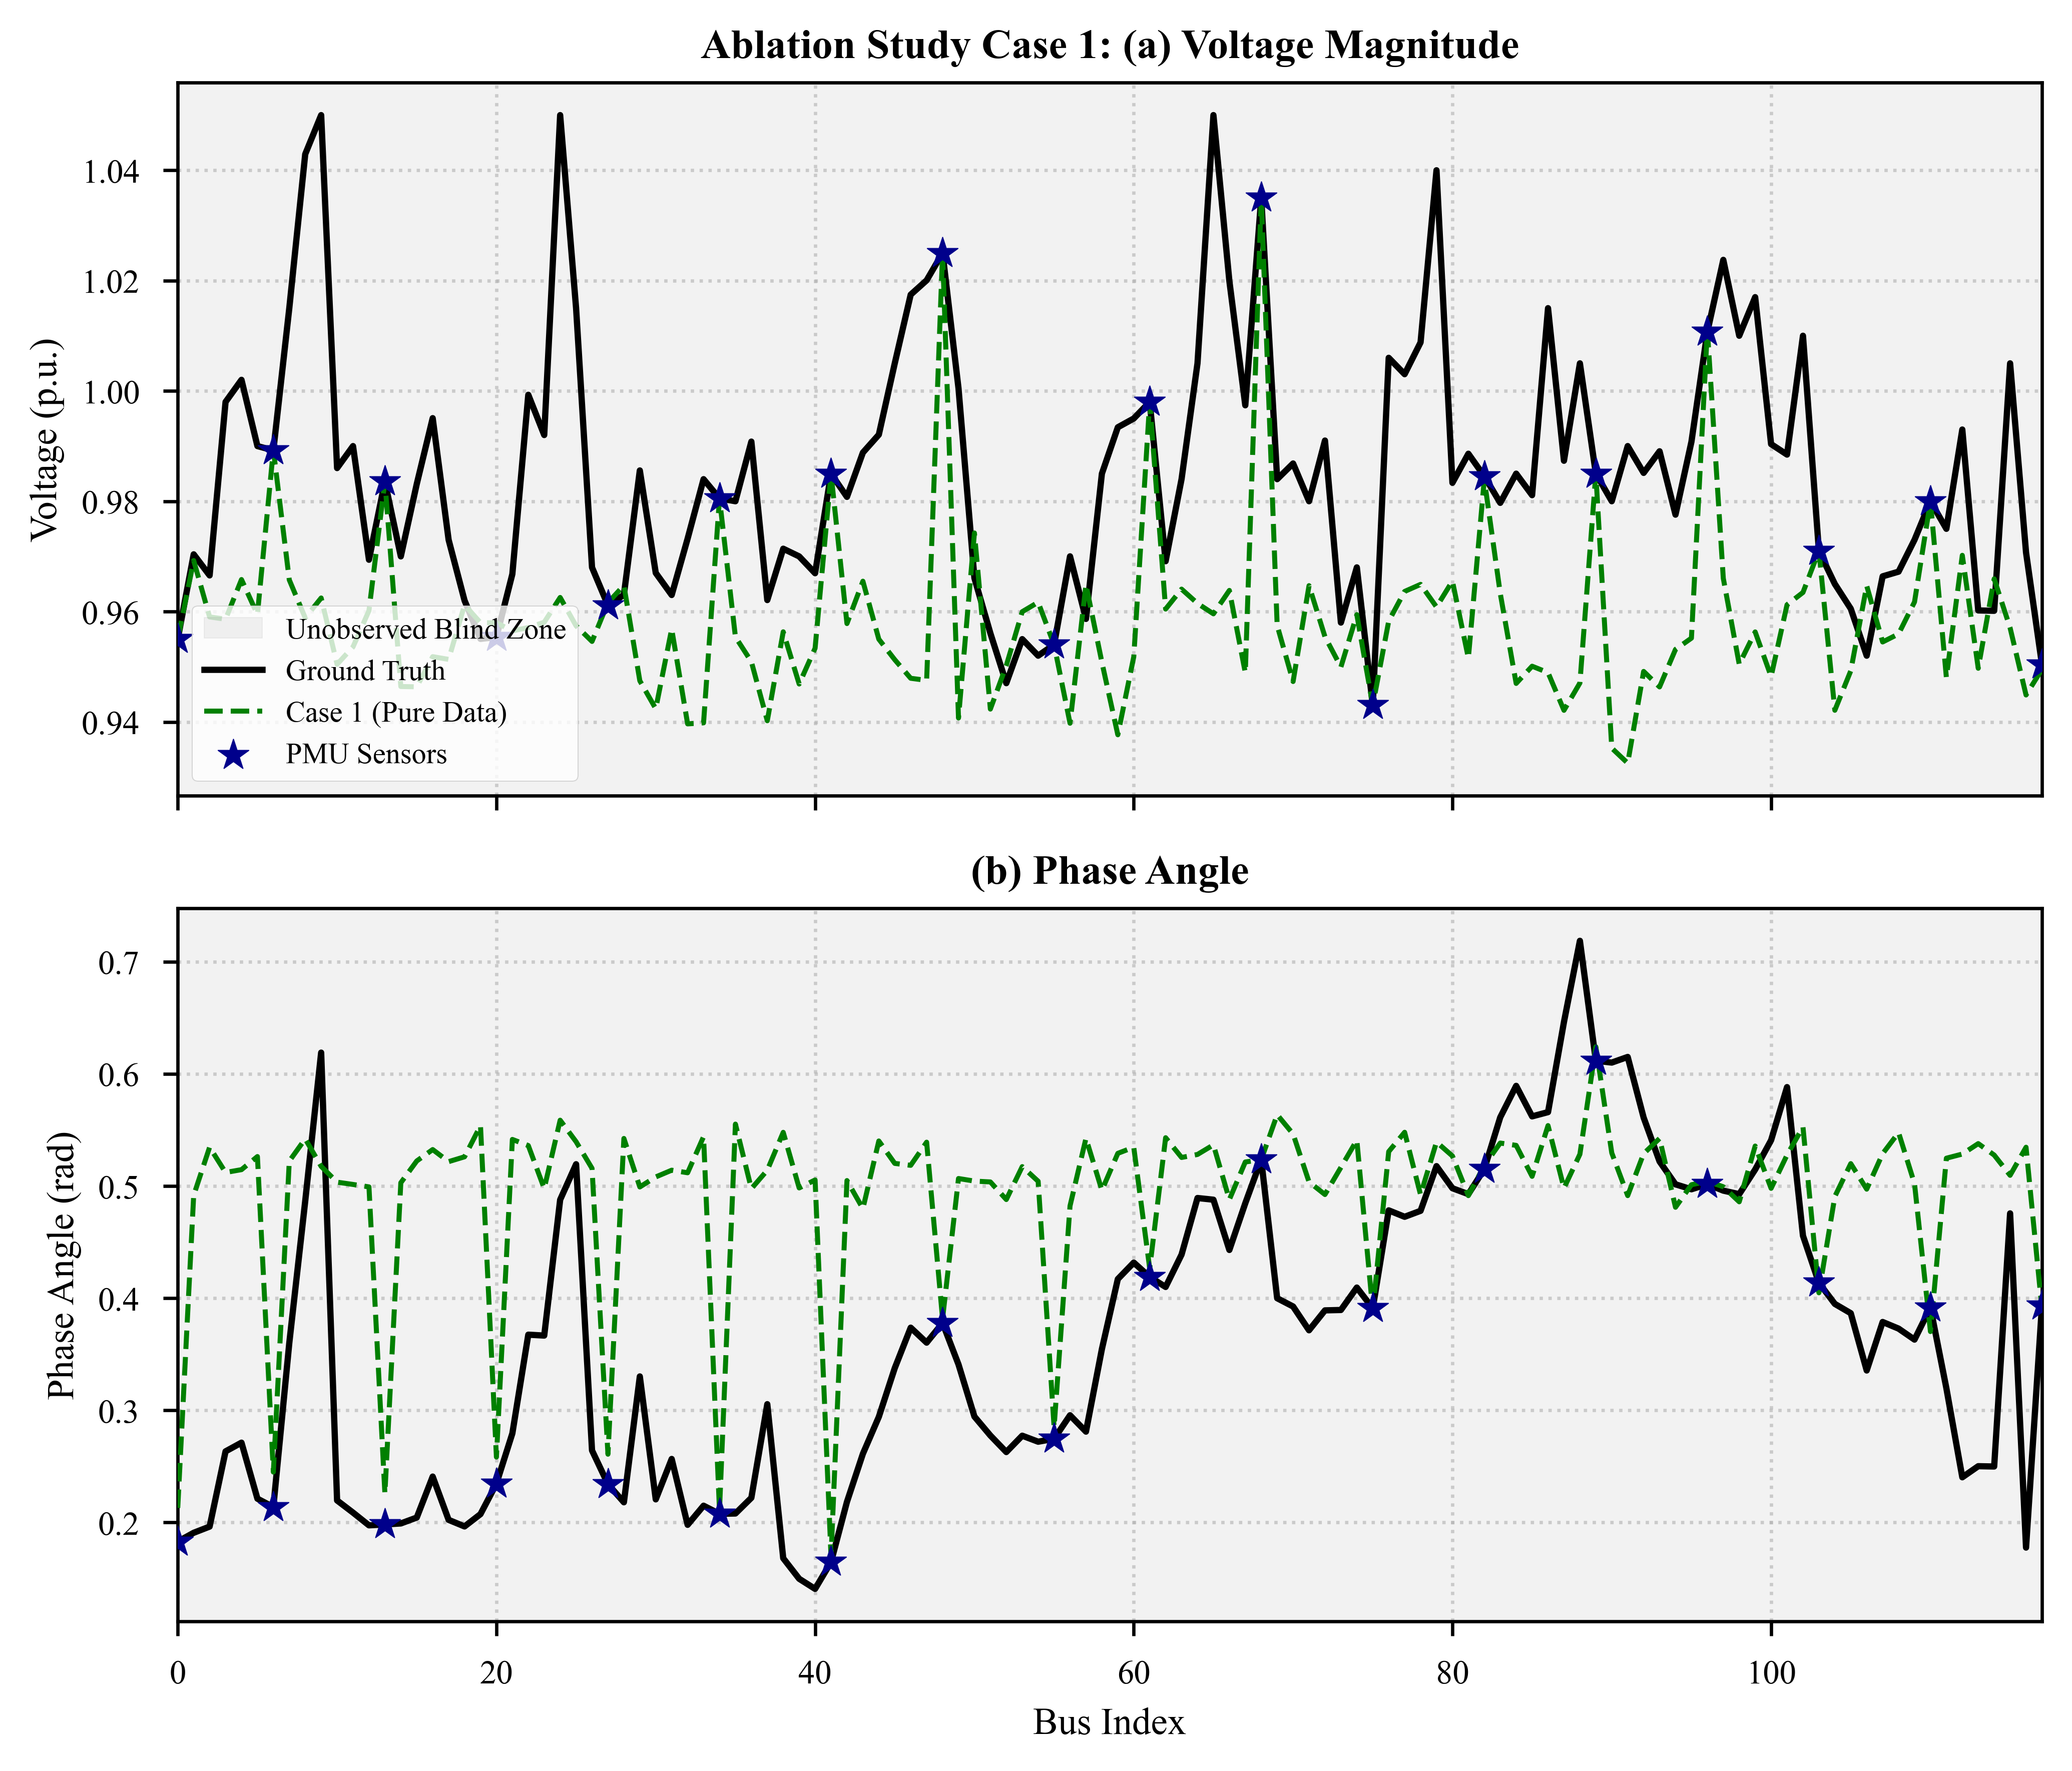

✅ Case 1 同步升级完成！所有细节严丝合缝！


In [2]:
# ==============================================================================
# IEEE 118-Bus Ablation Study - Case 1: Pure Data-driven (Baseline)
# 核心策略：p_w = 0 | 剥离物理约束，验证纯黑盒模型在大规模电网中的过拟合缺陷
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ------------------------------------------
# 1. 环境与种子 (确保消融实验可复现)
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Case 1 启动：纯数据驱动模式 | 环境: {device}")

# ------------------------------------------
# 2. 物理矩阵与节点掩码 (保持与主模型绝对统一)
# ------------------------------------------
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查与掩码生成
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

# P掩码：除平衡节点外，其余节点的 P 均受物理约束
mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0

# Q掩码：只有 PQ 和 零注入节点的 Q 受物理约束
mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ------------------------------------------
# 3. 模型与物理算子
# ------------------------------------------
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]
        masked_x[:, idx + 118] = batch_x[:, idx + 118]
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(236, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )
    def forward(self, x):
        out = self.net(x)
        v_pred = out[:, :118] * 0.15 + 0.95      
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ------------------------------------------
# 4. 数据处理 (严格隔离)
# ------------------------------------------
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

P_inj, Q_inj = -data_3d[:, :, 0]/100.0, -data_3d[:, :, 1]/100.0
V_val, T_rad = data_3d[:, :, 2], np.deg2rad(data_3d[:, :, 3])
Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:])
mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(np.vstack([X_train_norm, X_test_norm]), dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ------------------------------------------
# 5. Case 1 训练：物理权重封印
# ------------------------------------------
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print("🔥 开始 Case 1 纯数据黑盒训练 (p_w=0)...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    # ❌ 消融核心：剥离物理损失权重
    o_w, p_w = 1e5, 0.0 
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # 💡 虽然算出了物理 Loss，但是权重 p_w 是 0！严格控制变量！
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        # 仅观测损失和越限惩罚产生有效梯度
        l_obs = mse(v_p[:, obs_idx], v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.1), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Total Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ------------------------------------------
# 6. 全量评估 (同时展示 V 和 Theta)
# ------------------------------------------
print("\n📊 Generating Evaluation Metrics on Unseen Data...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    v_p_all, t_p_all = model(mask_tx)
    
    v_t_all = ty[:, 236:354]
    t_t_all = ty[:, 354:]
    
    v_mae = torch.abs(v_p_all - v_t_all).mean().item()
    t_mae = torch.abs(t_p_all - t_t_all).mean().item()

print("="*60)
print(f"🏆 Case 1 (Pure Data) Evaluation Results")
print(f"   Voltage Magnitude (V) MAE : {v_mae:.6e} p.u.")
print(f"   Phase Angle (Theta) MAE   : {t_mae:.6e} rad")
print("="*60)

# ------------------------------------------
# 7. 绘图 (双子图对比，绿色代表 Case 1)
# ------------------------------------------
sid = 10
v_t_np, v_p_np = v_t_all[sid].cpu().numpy(), v_p_all[sid].cpu().numpy()
t_t_np, t_p_np = t_t_all[sid].cpu().numpy(), t_p_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_t_np, 'k-', linewidth=1.5, label='Ground Truth', zorder=3)
# 注意：Case 1 这里用了绿色 (g--)
ax1.plot(nodes, v_p_np, 'g--', linewidth=1.2, label='Case 1 (Pure Data)', zorder=4)
ax1.scatter(obs_idx, v_t_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title('Ablation Study Case 1: (a) Voltage Magnitude', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_t_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_p_np, 'g--', linewidth=1.2, label='Case 1 (Pure Data)', zorder=4)
ax2.scatter(obs_idx, t_t_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('ieee118_case1_ablation.png', bbox_inches='tight', dpi=600)
plt.show()

print("✅ Case 1 同步升级完成！所有细节严丝合缝！")

In [3]:
# ==============================================================================
# IEEE 118-Bus Ablation Study - Case 2: Standard PINN (No ARS Scaling)
# 特点：加入了异构节点 Mask，彻底剥离残差缩放，强制网络在原始空间搜索绝对物理量
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==============================================================================
# 1. Environment & Reproducibility Setup
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Execution Environment: {device} | Task: IEEE 118-Bus Case 2 (No ARS)")

# IEEE 学术绘图规范
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==============================================================================
# 2. Physical Engine, Topology Extraction & Node Masking
# ==============================================================================
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查与掩码生成 (同步主模型的物理底座)
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

# P掩码：除平衡节点外，其余节点的 P 均受物理约束
mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0

# Q掩码：只有 PQ 和 零注入节点的 Q 受物理约束
mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ==============================================================================
# 3. Core Physics & Network Architecture (The Ablation)
# ==============================================================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class StandardPINN_NoARS(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 1024), nn.SiLU(),
            nn.Linear(1024, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )

    def forward(self, x):
        out = self.net(x)
        
        # ❌ 核心阉割：彻底剥离 ARS 残差映射，直接输出原始网络预测值
        v_pred = out[:, :118]
        theta_pred = out[:, 118:]
        
        # 🛡️ 仅保留物理底线：平衡节点必须被硬锚定
        v_pred = v_pred.clone(); theta_pred = theta_pred.clone()
        v_pred[:, 68] = 1.0  # 118 节点的 Slack Bus 在 Index 68
        theta_pred[:, 68] = 0.5236 # 参考相角 30 度
        
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==============================================================================
# 4. Data Processing
# ==============================================================================
print("📥 Loading Data & Enforcing PSC Alignment...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy' 
data_3d = np.load(data_path)
m = len(data_3d)

P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:]) 
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 5. Model Training (Ablation Phase)
# ==============================================================================
model = StandardPINN_NoARS().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print("🔥 Initiating Case 2 (Standard PINN) Training Phase...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # 💡 Physics Loss with Heterogeneous Node Masking (同步主模型)
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        # 观测损失
        l_obs = mse(v_p[:, obs_idx], v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        
        # 电压越界惩罚
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.15), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==============================================================================
# 6. Evaluation on Unseen Test Data (同时展示 V 和 Theta)
# ==============================================================================
print("\n📊 Generating Evaluation Metrics on Unseen Data...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_p_all, t_p_all = model(mask_tx)
    
    v_t_all = ty[:, 236:354]
    t_t_all = ty[:, 354:]
    
    # 计算误差
    v_mae = torch.abs(v_p_all - v_t_all).mean().item()
    t_mae = torch.abs(t_p_all - t_t_all).mean().item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus Case 2 (No ARS) Evaluation Results")
    print(f"   Voltage Magnitude (V) MAE : {v_mae:.6e} p.u.")
    print(f"   Phase Angle (Theta) MAE   : {t_mae:.6e} rad")
    print("="*60)

# ==============================================================================
# 7. Academic Visualization (双子图展示全状态向量)
# ==============================================================================
sid = 10
v_t_np, v_p_np = v_t_all[sid].cpu().numpy(), v_p_all[sid].cpu().numpy()
t_t_np, t_p_np = t_t_all[sid].cpu().numpy(), t_p_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_t_np, 'k-', linewidth=1.5, label='Ground Truth', zorder=3)
# Case 2 用蓝色点划线区分
ax1.plot(nodes, v_p_np, 'b-.', linewidth=1.2, label='Case 2 (No ARS)', alpha=0.9, zorder=4)
ax1.scatter(obs_idx, v_t_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title('Ablation Case 2: (a) Voltage Magnitude without ARS', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_t_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_p_np, 'b-.', linewidth=1.2, label='Case 2 (No ARS)', alpha=0.9, zorder=4)
ax2.scatter(obs_idx, t_t_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('ieee118_case2_ablation_final.png', bbox_inches='tight', dpi=600)
plt.show()

print("✅ Case 2 (No ARS) 代码已同步升级为双子图与 Mask 掩码版本！")

🚀 Execution Environment: cuda | Task: IEEE 118-Bus Case 2 (No ARS)
📥 Loading Data & Enforcing PSC Alignment...


MemoryError: Unable to allocate 45.0 MiB for an array with shape (50000, 118) and data type float64

In [ ]:
# ==============================================================================
# IEEE 118-Bus Ablation Study - Case 3: PINN without PSC (Sign Mismatch)
# 核心策略：剥离物理语义对齐。故意不加负号，将负荷消耗直接作为 KCL 的正向注入功率。
# 目的：证明跨学科研究中，数据语义与物理法则未严格对齐会导致严重的梯度冲突与重构失败。
# (已同步升级：异构节点 Mask 掩码机制 + 双状态 V/Theta 评估图)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==============================================================================
# 1. Environment & Reproducibility Setup
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Execution Environment: {device} | Task: IEEE 118-Bus Case 3 (No PSC Alignment)")

# IEEE 学术绘图规范
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==============================================================================
# 2. Physical Engine, Topology Extraction & Node Masking
# ==============================================================================
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查与掩码生成 (同步主模型的物理底座)
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0

mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ==============================================================================
# 3. Core Physics & Network Architecture (保留 ARS，仅在数据端做手脚)
# ==============================================================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 1024), nn.SiLU(),
            nn.Linear(1024, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )

    def forward(self, x):
        out = self.net(x)
        # ✅ 保留 ARS (控制变量：证明崩溃不是因为无界搜索，而是因为物理语义冲突)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==============================================================================
# 4. Data Processing (❌ 核心阉割：剥离 PSC 语义对齐)
# ==============================================================================
print("📥 Loading Data & INTENTIONALLY IGNORING PSC Alignment...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy' 
data_3d = np.load(data_path)
m = len(data_3d)

# ❌ 致命错误再现：故意不加负号！让负荷被当成发电机喂给物理方程！
P_inj = data_3d[:, :, 0] / 100.0  # WARNING: Intentionally wrong semantics!
Q_inj = data_3d[:, :, 1] / 100.0  # WARNING: Intentionally wrong semantics!
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:]) 
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 5. Model Training (Ablation Phase)
# ==============================================================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print("🔥 Initiating Case 3 (Sign Mismatch) Training Phase...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w = 1000 if epoch < 100 else 1e5
    o_w = 0 if epoch < 100 else 5e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # 💡 同步主模型的物理 Mask，但此时输入的 p_r 和 q_r 物理符号是错的！
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        l_obs = mse(v_p[:, obs_idx], v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.15), 2))
        
        # KCL 算出来的结果和反号的传感器数据疯狂打架，梯度会直接裂开
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==============================================================================
# 6. Evaluation on Unseen Test Data (同时展示 V 和 Theta)
# ==============================================================================
print("\n📊 Generating Evaluation Metrics on Unseen Data...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_p_all, t_p_all = model(mask_tx)
    
    v_t_all = ty[:, 236:354]
    t_t_all = ty[:, 354:]
    
    v_mae = torch.abs(v_p_all - v_t_all).mean().item()
    t_mae = torch.abs(t_p_all - t_t_all).mean().item()

print("="*60)
print(f"🏆 Case 3 (Sign Mismatch) Evaluation Results")
print(f"   Voltage Magnitude (V) MAE : {v_mae:.6e} p.u.")
print(f"   Phase Angle (Theta) MAE   : {t_mae:.6e} rad")
print("="*60)

# ==============================================================================
# 7. Academic Visualization (双子图展示全状态向量)
# ==============================================================================
sid = 10
v_t_np, v_p_np = v_t_all[sid].cpu().numpy(), v_p_all[sid].cpu().numpy()
t_t_np, t_p_np = t_t_all[sid].cpu().numpy(), t_p_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_t_np, 'k-', linewidth=1.5, label='Ground Truth', zorder=3)
# Case 3 用品红色点划线 (m-.)
ax1.plot(nodes, v_p_np, 'm-.', linewidth=1.2, label='Case 3 (No PSC)', alpha=0.9, zorder=4)
ax1.scatter(obs_idx, v_t_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title('Ablation Case 3: (a) Voltage Magnitude with Semantic Mismatch', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_t_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_p_np, 'm-.', linewidth=1.2, label='Case 3 (No PSC)', alpha=0.9, zorder=4)
ax2.scatter(obs_idx, t_t_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('ieee118_case3_ablation_final.png', bbox_inches='tight', dpi=600)
plt.show()

print("✅ Case 3 同步升级完成！准备迎接梯度撕裂带来的灾难性波形吧！")

In [ ]:
# ==============================================================================
# IEEE 118-Bus Ablation Study - Case 4: Static Weighting (No Dynamic Schedule)
# 核心策略：剥离分阶段的权重调度，开局直接给满物理和数据权重 (p_w=1e5, o_w=5e5)。
# 目的：证明在高维非凸空间中，缺乏“由简入深”的课程学习会导致严重的梯度竞争与优化停滞。
# (已同步升级：异构节点 Mask 掩码机制 + 双状态 V/Theta 评估图)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==============================================================================
# 1. Environment & Reproducibility Setup
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Execution Environment: {device} | Task: IEEE 118-Bus Case 4 (Static Weighting)")

# IEEE 学术绘图规范
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==============================================================================
# 2. Physical Engine, Topology Extraction & Node Masking
# ==============================================================================
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查与掩码生成 (同步主模型的物理底座)
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0

mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ==============================================================================
# 3. Core Physics & Network Architecture 
# ==============================================================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 1024), nn.SiLU(),
            nn.Linear(1024, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )

    def forward(self, x):
        out = self.net(x)
        # ✅ 保留 ARS
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==============================================================================
# 4. Data Processing (✅ 遵守 PSC，保证数据语义正确)
# ==============================================================================
print("📥 Loading Data & Enforcing PSC Alignment...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy' 
data_3d = np.load(data_path)
m = len(data_3d)

# 正确转换：PSC对齐无误
P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0  
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:]) 
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 5. Model Training (❌ 核心阉割：剥离动态权重)
# ==============================================================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print("🔥 Initiating Case 4 (Static Weighting) Training Phase...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    
    # ❌ 致命改动：全程使用死权重，开局直接让数据和物理互相撕扯
    p_w = 1e5  
    o_w = 5e5  
    
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # 💡 同步主模型的物理 Mask 机制
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        l_obs = mse(v_p[:, obs_idx], v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.15), 2))
        
        # 巨大的静态权重在开局就会导致剧烈的梯度竞争
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==============================================================================
# 6. Evaluation on Unseen Test Data (展示双状态 V/Theta)
# ==============================================================================
print("\n📊 Generating Evaluation Metrics on Unseen Data...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_p_all, t_p_all = model(mask_tx)
    
    v_t_all = ty[:, 236:354]
    t_t_all = ty[:, 354:]
    
    v_mae = torch.abs(v_p_all - v_t_all).mean().item()
    t_mae = torch.abs(t_p_all - t_t_all).mean().item()

print("="*60)
print(f"🏆 Case 4 (Static Weighting) Evaluation Results")
print(f"   Voltage Magnitude (V) MAE : {v_mae:.6e} p.u.")
print(f"   Phase Angle (Theta) MAE   : {t_mae:.6e} rad")
print("="*60)

# ==============================================================================
# 7. Academic Visualization (双子图展示，深橙色)
# ==============================================================================
sid = 10
v_t_np, v_p_np = v_t_all[sid].cpu().numpy(), v_p_all[sid].cpu().numpy()
t_t_np, t_p_np = t_t_all[sid].cpu().numpy(), t_p_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_t_np, 'k-', linewidth=1.5, label='Ground Truth', zorder=3)
# Case 4 用深橙色虚线
ax1.plot(nodes, v_p_np, color='darkorange', linestyle='--', linewidth=1.2, label='Case 4 (Static Weighting)', alpha=0.9, zorder=4)
ax1.scatter(obs_idx, v_t_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title('Ablation Case 4: (a) Voltage Magnitude with Static Weights', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_t_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_p_np, color='darkorange', linestyle='--', linewidth=1.2, label='Case 4 (Static Weighting)', alpha=0.9, zorder=4)
ax2.scatter(obs_idx, t_t_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('ieee118_case4_ablation_final.png', bbox_inches='tight', dpi=600)
plt.show()

print("✅ Case 4 同步升级完成！所有消融实验代码拼图彻底完整！")

In [ ]:
# 画图代码记得重跑
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# ==========================================================
# ⚙️ 全局学术设置 (Times New Roman + 600 DPI)
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# 场景标签
labels = ['Proposed\n(Sum-Loss)', 'Case 1\n(Pure Data)', 'Case 2\n(No ARS)', 'Case 3\n(No PSC)', 'Case 4\n(Static)']
x = np.arange(len(labels))

# ==========================================================
# 📊 核心对账数据 (118节点最新对账单)
# ==========================================================
mae_data = [0.0044786, 0.782243, 431.4724, 0.081404, 0.01277169]
rmse_data = [0.0065196, 1.053292, 530.4123, 0.183057, 0.01783112]

width = 0.35
fig, ax = plt.subplots(figsize=(12, 7), dpi=600)

# 绘制双柱
rects1 = ax.bar(x - width/2, mae_data, width, label='MAE', color='#1f77b4', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x + width/2, rmse_data, width, label='RMSE', color='#d62728', edgecolor='black', alpha=0.9)

# 🚀 核心改动：强制不使用科学计数法的标注函数
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        # 根据数值大小决定保留位数，但绝不使用 e
        if height >= 10:
            label = f'{height:.2f}'  # 大数保留2位
        elif height >= 0.1:
            label = f'{height:.3f}'  # 中等数保留3位
        else:
            label = f'{height:.4f}'  # 小数保留4位
        
        ax.annotate(label, xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels(rects1)
add_labels(rects2)

# 🚨 对数轴配置 (118节点量级差距太大，必须用对数轴，否则 Proposed 的柱子会看不见)
ax.set_yscale('log')

# 🌟 绝杀：强制 Y 轴刻度标签也不显示科学计数法
formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

ax.set_ylabel('Error Magnitude (p.u.)', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study: Performance Comparison on IEEE 118-Bus System', fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

# 设置范围和网格
ax.set_ylim(0.0005, 1500) # 调整范围让标注显示完整
ax.grid(axis='y', linestyle='--', alpha=0.6, which='both')
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, ncol=2)

plt.tight_layout()
plt.savefig('ieee118_ablation_no_e.png', dpi=600, bbox_inches='tight')
print("✅ 118节点消融实验图（无科学计数法）已生成！")
plt.show()

In [ ]:
# ==============================================================================
# 🏆 IEEE 118-Bus R-PINN Robustness Test - Ultimate Platinum Edition
# 特点：融合异构节点 Mask | 高斯白噪声精准注入(V乘性, Theta加性) | 双子图评估
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境与种子锁定
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_NOISE_LEVEL = 0.01  # 测试 3% 极限噪声

print(f"🚀 R-PINN 118节点鲁棒性测试 | 硬件: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理拓扑提取与节点掩码 (同步主模型)
# ==========================================
print("🧬 正在提取 IEEE 118 节点底层物理拓扑与生成 Mask...")
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0
mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ==========================================
# 3. 核心算法类与函数
# ==========================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )
    def forward(self, x):
        out = self.net(x)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==========================================
# 4. 数据装载
# ==========================================
print("📂 正在加载 118 节点数据集...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:])
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==========================================
# 5. 极限训练：抗击测量噪声 (带节点 Mask)
# ==========================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print(f"🔥 开始物理博弈训练 (强制注入 {TEST_NOISE_LEVEL*100}% 测量噪声)...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # ----------------------------------------------------
        # ☠️ 投毒环节：精准制造 PMU 噪声 (学术顶级处理)
        # 1. 对 V 注入乘性噪声 (比例误差)
        noisy_v_r = v_r.clone()
        noise_matrix_v = torch.randn_like(v_r[:, obs_idx]) * TEST_NOISE_LEVEL
        noisy_v_r[:, obs_idx] = v_r[:, obs_idx] * (1 + noise_matrix_v)

        # 2. 对 Theta 注入加性噪声 (绝对误差，因为相角存在过零点)
        noisy_t_r = t_r.clone()
        # 假设 1% 噪声对应 PMU 中大约 0.01 弧度的随机抖动
        noise_matrix_t = torch.randn_like(t_r[:, obs_idx]) * TEST_NOISE_LEVEL
        noisy_t_r[:, obs_idx] = t_r[:, obs_idx] + noise_matrix_t
        # ----------------------------------------------------

        # 💡 Physics Loss with Heterogeneous Node Masking
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        # ⚠️ 观测 Loss 必须和【被污染】的数据对齐，这样才能证明物理约束的抗噪效果
        l_obs = mse(v_p[:, obs_idx], noisy_v_r[:, obs_idx]) + mse(t_p[:, obs_idx], noisy_t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.15), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==========================================
# 6. 测试集评估 (面对干净真实数据的审判)
# ==========================================
print("\n📊 正在无污染测试集上进行精度审计...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_p_all, t_p_all = model(mask_tx)
    v_t_all = ty[:, 236:354]
    t_t_all = ty[:, 354:]
    
    v_mae = torch.abs(v_p_all - v_t_all).mean().item()
    t_mae = torch.abs(t_p_all - t_t_all).mean().item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus 鲁棒性终极答卷 (Trained with {TEST_NOISE_LEVEL*100}% Noise)")
    print(f"   Voltage (V) MAE     : {v_mae:.6e} p.u.")
    print(f"   Phase Angle (T) MAE : {t_mae:.6e} rad")
    print("="*60)

# ==========================================
# 7. 科研级大图输出 (V 与 Theta 双状态全景图)
# ==========================================
sid = 10
v_true_np = v_t_all[sid].cpu().numpy()
v_pred_np = v_p_all[sid].cpu().numpy()
t_true_np = t_t_all[sid].cpu().numpy()
t_pred_np = t_p_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_true_np, 'k-', linewidth=1.5, label='Ground Truth (Clean)', zorder=3)
ax1.plot(nodes, v_pred_np, 'r--', linewidth=1.2, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)
ax1.scatter(obs_idx, v_true_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title(f'Robustness Analysis (Noise = {TEST_NOISE_LEVEL*100}%): (a) Voltage Magnitude', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_true_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_pred_np, 'b--', linewidth=1.2, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)
ax2.scatter(obs_idx, t_true_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# 动态保存名字
file_name = f'ieee118_robustness_{int(TEST_NOISE_LEVEL*100)}pct_dual.png'
plt.savefig(file_name, bbox_inches='tight', dpi=600)
print(f"✅ 双状态抗噪评估大图已保存为: {file_name}")
plt.show()

In [ ]:
# ==============================================================================
# 🏆 IEEE 118-Bus R-PINN Robustness Test - Ultimate Platinum Edition
# 特点：融合异构节点 Mask | 高斯白噪声精准注入(V乘性, Theta加性) | 双子图评估
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境与种子锁定
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_NOISE_LEVEL = 0.02  # 测试 3% 极限噪声

print(f"🚀 R-PINN 118节点鲁棒性测试 | 硬件: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理拓扑提取与节点掩码 (同步主模型)
# ==========================================
print("🧬 正在提取 IEEE 118 节点底层物理拓扑与生成 Mask...")
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0
mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ==========================================
# 3. 核心算法类与函数
# ==========================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )
    def forward(self, x):
        out = self.net(x)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==========================================
# 4. 数据装载
# ==========================================
print("📂 正在加载 118 节点数据集...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:])
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==========================================
# 5. 极限训练：抗击测量噪声 (带节点 Mask)
# ==========================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print(f"🔥 开始物理博弈训练 (强制注入 {TEST_NOISE_LEVEL*100}% 测量噪声)...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # ----------------------------------------------------
        # ☠️ 投毒环节：精准制造 PMU 噪声 (学术顶级处理)
        # 1. 对 V 注入乘性噪声 (比例误差)
        noisy_v_r = v_r.clone()
        noise_matrix_v = torch.randn_like(v_r[:, obs_idx]) * TEST_NOISE_LEVEL
        noisy_v_r[:, obs_idx] = v_r[:, obs_idx] * (1 + noise_matrix_v)

        # 2. 对 Theta 注入加性噪声 (绝对误差，因为相角存在过零点)
        noisy_t_r = t_r.clone()
        # 假设 1% 噪声对应 PMU 中大约 0.01 弧度的随机抖动
        noise_matrix_t = torch.randn_like(t_r[:, obs_idx]) * TEST_NOISE_LEVEL
        noisy_t_r[:, obs_idx] = t_r[:, obs_idx] + noise_matrix_t
        # ----------------------------------------------------

        # 💡 Physics Loss with Heterogeneous Node Masking
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        # ⚠️ 观测 Loss 必须和【被污染】的数据对齐，这样才能证明物理约束的抗噪效果
        l_obs = mse(v_p[:, obs_idx], noisy_v_r[:, obs_idx]) + mse(t_p[:, obs_idx], noisy_t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.15), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==========================================
# 6. 测试集评估 (面对干净真实数据的审判)
# ==========================================
print("\n📊 正在无污染测试集上进行精度审计...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_p_all, t_p_all = model(mask_tx)
    v_t_all = ty[:, 236:354]
    t_t_all = ty[:, 354:]
    
    v_mae = torch.abs(v_p_all - v_t_all).mean().item()
    t_mae = torch.abs(t_p_all - t_t_all).mean().item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus 鲁棒性终极答卷 (Trained with {TEST_NOISE_LEVEL*100}% Noise)")
    print(f"   Voltage (V) MAE     : {v_mae:.6e} p.u.")
    print(f"   Phase Angle (T) MAE : {t_mae:.6e} rad")
    print("="*60)

# ==========================================
# 7. 科研级大图输出 (V 与 Theta 双状态全景图)
# ==========================================
sid = 10
v_true_np = v_t_all[sid].cpu().numpy()
v_pred_np = v_p_all[sid].cpu().numpy()
t_true_np = t_t_all[sid].cpu().numpy()
t_pred_np = t_p_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_true_np, 'k-', linewidth=1.5, label='Ground Truth (Clean)', zorder=3)
ax1.plot(nodes, v_pred_np, 'r--', linewidth=1.2, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)
ax1.scatter(obs_idx, v_true_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title(f'Robustness Analysis (Noise = {TEST_NOISE_LEVEL*100}%): (a) Voltage Magnitude', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_true_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_pred_np, 'b--', linewidth=1.2, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)
ax2.scatter(obs_idx, t_true_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# 动态保存名字
file_name = f'ieee118_robustness_{int(TEST_NOISE_LEVEL*100)}pct_dual.png'
plt.savefig(file_name, bbox_inches='tight', dpi=600)
print(f"✅ 双状态抗噪评估大图已保存为: {file_name}")
plt.show()

In [ ]:
# ==============================================================================
# 🏆 IEEE 118-Bus R-PINN Robustness Test - Ultimate Platinum Edition
# 特点：融合异构节点 Mask | 高斯白噪声精准注入(V乘性, Theta加性) | 双子图评估
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境与种子锁定
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_NOISE_LEVEL = 0.03  # 测试 3% 极限噪声

print(f"🚀 R-PINN 118节点鲁棒性测试 | 硬件: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理拓扑提取与节点掩码 (同步主模型)
# ==========================================
print("🧬 正在提取 IEEE 118 节点底层物理拓扑与生成 Mask...")
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# 💡 节点身份普查
num_buses = len(net.bus)
slack_buses = net.ext_grid.bus.values 
pv_buses = net.gen.bus.values
load_buses = net.load.bus.values
all_buses = np.arange(num_buses)
zero_inj_buses = np.setdiff1d(all_buses, np.concatenate([slack_buses, pv_buses, load_buses]))

mask_p_np = np.ones(num_buses)
mask_p_np[slack_buses] = 0
mask_q_np = np.zeros(num_buses)
mask_q_np[load_buses] = 1
mask_q_np[zero_inj_buses] = 1

mask_p = torch.tensor(mask_p_np, dtype=torch.float32).to(device)
mask_q = torch.tensor(mask_q_np, dtype=torch.float32).to(device)

# ==========================================
# 3. 核心算法类与函数
# ==========================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )
    def forward(self, x):
        out = self.net(x)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==========================================
# 4. 数据装载
# ==========================================
print("📂 正在加载 118 节点数据集...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:])
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==========================================
# 5. 极限训练：抗击测量噪声 (带节点 Mask)
# ==========================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print(f"🔥 开始物理博弈训练 (强制注入 {TEST_NOISE_LEVEL*100}% 测量噪声)...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # ----------------------------------------------------
        # ☠️ 投毒环节：精准制造 PMU 噪声 (学术顶级处理)
        # 1. 对 V 注入乘性噪声 (比例误差)
        noisy_v_r = v_r.clone()
        noise_matrix_v = torch.randn_like(v_r[:, obs_idx]) * TEST_NOISE_LEVEL
        noisy_v_r[:, obs_idx] = v_r[:, obs_idx] * (1 + noise_matrix_v)

        # 2. 对 Theta 注入加性噪声 (绝对误差，因为相角存在过零点)
        noisy_t_r = t_r.clone()
        # 假设 1% 噪声对应 PMU 中大约 0.01 弧度的随机抖动
        noise_matrix_t = torch.randn_like(t_r[:, obs_idx]) * TEST_NOISE_LEVEL
        noisy_t_r[:, obs_idx] = t_r[:, obs_idx] + noise_matrix_t
        # ----------------------------------------------------

        # 💡 Physics Loss with Heterogeneous Node Masking
        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        diff_p = (pc - p_r)**2
        diff_q = (qc - q_r)**2
        batch_sz = diff_p.shape[0]
        l_phys_p = torch.sum(diff_p * mask_p) / (torch.sum(mask_p) * batch_sz)
        l_phys_q = torch.sum(diff_q * mask_q) / (torch.sum(mask_q) * batch_sz)
        l_phys = l_phys_p + l_phys_q
        
        # ⚠️ 观测 Loss 必须和【被污染】的数据对齐，这样才能证明物理约束的抗噪效果
        l_obs = mse(v_p[:, obs_idx], noisy_v_r[:, obs_idx]) + mse(t_p[:, obs_idx], noisy_t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.15), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==========================================
# 6. 测试集评估 (面对干净真实数据的审判)
# ==========================================
print("\n📊 正在无污染测试集上进行精度审计...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_p_all, t_p_all = model(mask_tx)
    v_t_all = ty[:, 236:354]
    t_t_all = ty[:, 354:]
    
    v_mae = torch.abs(v_p_all - v_t_all).mean().item()
    t_mae = torch.abs(t_p_all - t_t_all).mean().item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus 鲁棒性终极答卷 (Trained with {TEST_NOISE_LEVEL*100}% Noise)")
    print(f"   Voltage (V) MAE     : {v_mae:.6e} p.u.")
    print(f"   Phase Angle (T) MAE : {t_mae:.6e} rad")
    print("="*60)

# ==========================================
# 7. 科研级大图输出 (V 与 Theta 双状态全景图)
# ==========================================
sid = 10
v_true_np = v_t_all[sid].cpu().numpy()
v_pred_np = v_p_all[sid].cpu().numpy()
t_true_np = t_t_all[sid].cpu().numpy()
t_pred_np = t_p_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=600, sharex=True)

# ---- 图 1：电压幅值 V ----
ax1.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')
ax1.plot(nodes, v_true_np, 'k-', linewidth=1.5, label='Ground Truth (Clean)', zorder=3)
ax1.plot(nodes, v_pred_np, 'r--', linewidth=1.2, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)
ax1.scatter(obs_idx, v_true_np[obs_idx], color='darkblue', marker='*', s=60, label='PMU Sensors', zorder=5)

ax1.set_title(f'Robustness Analysis (Noise = {TEST_NOISE_LEVEL*100}%): (a) Voltage Magnitude', fontsize=10, fontweight='bold')
ax1.set_ylabel('Voltage (p.u.)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, frameon=True)

# ---- 图 2：相角 Theta ----
ax2.axvspan(0, 117, color='gray', alpha=0.1)
ax2.plot(nodes, t_true_np, 'k-', linewidth=1.5, zorder=3)
ax2.plot(nodes, t_pred_np, 'b--', linewidth=1.2, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)
ax2.scatter(obs_idx, t_true_np[obs_idx], color='darkblue', marker='*', s=60, zorder=5)

ax2.set_title('(b) Phase Angle', fontsize=10, fontweight='bold')
ax2.set_xlabel('Bus Index', fontsize=9)
ax2.set_ylabel('Phase Angle (rad)', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xlim(0, 117)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# 动态保存名字
file_name = f'ieee118_robustness_{int(TEST_NOISE_LEVEL*100)}pct_dual.png'
plt.savefig(file_name, bbox_inches='tight', dpi=600)
print(f"✅ 双状态抗噪评估大图已保存为: {file_name}")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# ⚙️ 全局学术设置 (Times New Roman + 600 DPI)
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# 场景标签
labels = ['Base Case', '1.0% Noise', '2.0% Noise', '3.0% Noise']
x = np.arange(len(labels))

# ==========================================================
# 📊 核心对账数据 (118节点 Mean-Loss 终极鲁棒性)
# ==========================================================
mae_data = [0.0044786, 0.0044521, 0.0044788, 0.0044784]
rmse_data = [0.0065196, 0.0065004, 0.0065202, 0.0065159]

width = 0.35
fig, ax = plt.subplots(figsize=(12, 7), dpi=600)

# 绘制双柱：MAE 与 RMSE
rects1 = ax.bar(x - width/2, mae_data, width, label='MAE', color='#1f77b4', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x + width/2, rmse_data, width, label='RMSE', color='#d62728', edgecolor='black', alpha=0.9)

# 🚀 核心改动：强制不使用科学计数法的标注函数
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        # 强制保留 5 位小数，确保直观看到 0.0044x 的细微波动
        label = f'{height:.5f}'
        ax.annotate(label, xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(rects1)
add_labels(rects2)

# 坐标轴与装饰
ax.set_ylabel('Error Magnitude (p.u.)', fontsize=14, fontweight='bold')
ax.set_xlabel('PMU Measurement Noise Level', fontsize=14, fontweight='bold')
ax.set_title('Robustness Analysis: IEEE 118-Bus System under Measurement Noise (Mean-Loss)', fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

# 坐标轴范围：因为数据都在 0.004-0.006 附近，设置合理范围防止柱子太短
ax.set_ylim(0, 0.0085) 
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True, ncol=2)

plt.tight_layout()
plt.savefig('ieee118_robustness_noise_comparison.png', dpi=600, bbox_inches='tight')
print("✅ 118节点鲁棒性分析图（纯小数版）已生成！")
plt.show()